# Practical 10: **SqueezeNet (Fire Modules)**

In this practical, we continue our CNN journey from **AlexNet → VGG‑16 → GoogLeNet** to **SqueezeNet**, a network that achieves **AlexNet‑level accuracy with dramatically fewer parameters** using clever architectural ideas called **Fire modules**.

> As in Practicals **7, 8, and 9**, we will use the **same flowers dataset**, the **same data pipeline**, and the **same evaluation & prediction visualizations** to make results comparable across models.

**You’ll learn to:**
- Understand SqueezeNet’s **Fire module** (squeeze 1×1 → expand {1×1, 3×3}).
- See why SqueezeNet is **parameter‑efficient** (1×1 conv usage + late downsampling).
- Fine‑tune SqueezeNet on the **same flowers dataset** you used before.
- Evaluate with **accuracy, classification report, confusion matrix**, and a **prediction gallery**.
- Compare **parameter counts** with **AlexNet, VGG‑16, GoogLeNet**.

## Learning Goals

- Reuse the **exact same** dataset setup (train/val/test splits), transforms, loaders, metrics, and plots as Practicals **7–9**.
- Build and inspect **SqueezeNet v1.0**; replace the final classifier for our flower classes.
- Understand SqueezeNet vs **AlexNet / VGG‑16 / GoogLeNet** in terms of **structure and parameters**.
- Train (or fine‑tune) and evaluate using **the same functions and outputs** for side‑by‑side comparability.
- Save the best model and visualize predictions, just like before.


## Dataset

- We will use the **same flowers dataset** and **identical transforms & loaders** so the results remain consistent across notebooks.
- Download the **flowers dataset** from my Google Drive: [Flowers Dataset Link](https://drive.google.com/file/d/1Oaghg3cBXOD88LAfa5pWXzuHtiJ93o7O/view?usp=sharing)

> If you changed the path in earlier practicals, please update `DATA_DIR` below to the same value.


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ===== Keep names identical to earlier practicals =====
# (Adjust DATA_DIR to your path if needed; structure must match previous practicals)
import os, copy, time, math, itertools, json
from typing import Tuple, List

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms, models

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, precision_score, accuracy_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

#DATA_DIR = "/content/drive/MyDrive/flowers"  # <-- change only if your earlier practicals used a different path
DATA_DIR = "flowers"
# Image transforms: keep consistent with Practicals 7–9 (ImageNet stats + augment for train)
IMG_SIZE = 224
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
eval_tfms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE*1.15)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Datasets & Loaders (same API/params)
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_tfms)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"),   transform=eval_tfms)
test_ds  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"),  transform=eval_tfms)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

BATCH_SIZE = 100
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Device: cuda
Classes: ['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']


## SqueezeNet: Fire Modules for **Parameter Efficiency**

SqueezeNet dramatically reduces parameters while keeping accuracy competitive with AlexNet by using two main ideas:

1) **Fire module** (the core building block):
```
Input
  └─ Squeeze: 1×1 conv with s1x1 filters  → reduces channels (bottleneck)
        └─ Expand: {1×1 conv (e1x1 filters), 3×3 conv (e3x3 filters)} in parallel
             └─ Concatenate along channel dimension → output
```
- The **squeeze** 1×1 conv reduces the number of input channels flowing into the more expensive 3×3 convs.
- The **expand** stage restores representational power using both 1×1 and 3×3 filters, then concatenates them.

2) **Late downsampling**
- Pooling (spatial downsampling) is delayed to later layers to keep **larger activation maps** in earlier layers, improving accuracy without increasing parameters.

### Macro‑architecture (SqueezeNet v1.0)
A typical high‑level layout (input 224×224):
```
conv1 (7×7, stride 2) → maxpool
fire2 → fire3 → maxpool
fire4 → fire5 → maxpool
fire6 → fire7 → fire8 → fire9
conv10 (1×1) → global avg pool → softmax
```
> **v1.1** uses a smaller conv1 (3×3) and a few stride adjustments to be faster on embedded devices; we use **v1.0** here for parity with classic reports.

### **Fire Module Architecture:**

<center>
<img src="images/fire-module-architecture.png" alt="Fire Module" width="500"/>
</center>

### Why fewer parameters than **AlexNet** and **VGG‑16**?
- Heavy use of **1×1 convs** (cheap: 1×1×C vs 3×3×C)
- **Squeeze** bottleneck limits the number of channels entering expensive 3×3s
- No huge **fully‑connected** classifier (replaced by 1×1 conv + global average pooling)
- **Late downsampling** preserves accuracy while keeping parameter count low

## Design Comparison: AlexNet vs VGG‑16 vs GoogLeNet vs SqueezeNet

| Model | Core Idea | Param Scale | Classifier | Notable Tricks |
|---|---|---:|---|---|
| **AlexNet (2012)** | 5 conv + 3 FC | ~60–61M | **Large FC** layers | ReLU, Dropout, Data Aug, GPU training |
| **VGG‑16 (2014)** | Many **3×3** convs | ~138M | 3 FC layers | Deep but simple blocks |
| **GoogLeNet (2014)** | **Inception** multi‑branch | ~6.8–7M | GAP + Linear | 1×1 reductions, aux heads |
| **SqueezeNet (2016)** | **Fire** modules (1×1 squeeze) | **~1.2–1.3M** | 1×1 conv + **GAP** | Late downsampling, heavy 1×1 use |

> We will empirically compare **parameter counts** below using the exact same code utilities as in earlier practicals.


# How It Recognizes Flowers

## The Minimalist Botanist

**Think of SqueezeNet as a botanical expert who gives perfect flower identification using only essential information.**

### Step-by-Step Process:

**1. Initial Processing:**
- Standard convolution establishes basic image understanding
- **Flower detection**: "Something botanical is present"

**2. Fire Modules: Squeeze-Then-Expand Strategy**

Each Fire Module works in two phases:

**Squeeze Phase (Compression):**
- **1×1 filters** compress information drastically
- Like a master botanist selecting only essential flower characteristics
- **Flower detection**: "From 256 features, here are the 32 most important flower-identifying ones"

**Expand Phase (Smart Recovery):**
- **1×1 path**: Refines compressed features for fine botanical details
- **3×3 path**: Adds spatial context to compressed features
- **Flower detection**: "Fine petal details + spatial flower context = confident flower features"

**3. Progressive Fire Modules:**
- **Fire2-3**: "Essential basic flower features identified"
  - Color patterns, basic petal shapes
- **Fire4-6**: "Flower parts (petals, center, overall shape) confirmed"
  - Tulip: "Cup shape + simple petal arrangement"
  - Lotus: "Circular arrangement + water lily characteristics"
- **Fire7-9**: "Complete flower structure validated"
  - Sunflower: "Large size + yellow petals + dark center confirmed"

**4. Final Decision:**
- **Global average pooling** (no heavy fully connected layers)
- **Output**: "85% confident this is a Tulip - and I used only 1.25M parameters!"

### SqueezeNet's Character:
- **Efficient**: Maximum flower recognition with minimum resources
- **Smart**: Knows exactly what botanical information to keep and discard
- **Mobile-ready**: Perfect for field botany apps on smartphones

### How SqueezeNet Improves on Previous Models:

| Aspect | AlexNet | VGGNet | GoogleNet | SqueezeNet |
|--------|---------|---------|-----------|------------|
| **Model Size** | 240MB | 528MB | 20MB | 5MB |
| **Parameters** | 60M | 138M | 5M | 1.25M |
| **Field Deployment** | Impossible | Impossible | Challenging | Easy |
| **Flower Recognition** | Heavy processing | Very heavy | Smart processing | Ultra-efficient |
| **Innovation** | Depth | Systematic depth | Multi-scale | Extreme efficiency |
| **Accuracy** | 85% | 92% | 93% | 85% |

**Key Improvement**: SqueezeNet achieves AlexNet-level flower recognition accuracy with 50× fewer parameters, making botanical AI accessible on mobile devices for field identification - something impossible with earlier models.

## Inspecting **SqueezeNet** Structure and Parameters

Below we:
1) Load **SqueezeNet v1.0** (attempt pretrained weights; fallback if unavailable).
2) Replace the final classifier to output `num_classes` flower categories.
3) Decide whether to **freeze** the feature extractor (optionally fine‑tune all).
4) Print a **parameter breakdown** per submodule and compare total parameters to AlexNet/VGG‑16/GoogLeNet.


In [2]:
from typing import Tuple, List

def count_params(model: nn.Module) -> Tuple[int, int]:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def module_param_count(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters())

def walk_submodules(m: nn.Module, prefix="") -> List[Tuple[str, nn.Module, int]]:
    out = []
    for name, child in m.named_children():
        full = f"{prefix}.{name}" if prefix else name
        out.append((full, child, module_param_count(child)))
        out.extend(walk_submodules(child, prefix=full))
    return out

# --- Load SqueezeNet (with robust weights handling across torchvision versions) ---
try:
    sq = models.squeezenet1_0(weights=models.SqueezeNet1_0_Weights.IMAGENET1K_V1)
except Exception:
    try:
        sq = models.squeezenet1_0(pretrained=True)
    except Exception:
        sq = models.squeezenet1_0()

# Replace classifier for our dataset
# SqueezeNet's classifier is: Sequential( Dropout, Conv2d(512 -> 1000, 1x1), ReLU, AvgPool )
sq.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=1)
sq.num_classes = num_classes

# --- Fine‑tuning policy ---
FREEZE_BACKBONE = True  # set False to fine‑tune everything
for name, p in sq.named_parameters():
    if name.startswith('classifier.1'):  # our new conv layer
        p.requires_grad = True
    else:
        p.requires_grad = not FREEZE_BACKBONE

sq = sq.to(device)

# Print structure summary
print(sq)

# Parameter counts
total, trainable = count_params(sq)
print(f"\nSqueezeNet v1.0 → Total params: {total/1e6:.2f}M | Trainable: {trainable/1e6:.2f}M\n")

# Per‑submodule breakdown (top 20 by params)
subs = walk_submodules(sq)
subs_sorted = sorted(subs, key=lambda t: t[2], reverse=True)
for name, mod, pc in subs_sorted[:20]:
    print(f"{name:40s} -> {pc/1e6:6.3f} M  ({type(mod).__name__})")

SqueezeNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(7, 7), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (3): Fire(
      (squeeze): Conv2d(96, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (4): Fire(
      (squeeze): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (5): Fire(
   

In [3]:
# Optional: Compare parameter counts with AlexNet, VGG‑16, GoogLeNet (no training here)
def safe_load(model_fn, weight_attr=None):
    try:
        if weight_attr is not None:
            return model_fn(weights=weight_attr)
        return model_fn(pretrained=True)
    except Exception:
        return model_fn()

alex = safe_load(models.alexnet, getattr(models, 'AlexNet_Weights', None).IMAGENET1K_V1 if hasattr(models, 'AlexNet_Weights') else None)
vgg16 = safe_load(models.vgg16, getattr(models, 'VGG16_Weights', None).IMAGENET1K_V1 if hasattr(models, 'VGG16_Weights') else None)
goog = safe_load(models.googlenet, getattr(models, 'GoogLeNet_Weights', None).IMAGENET1K_V1 if hasattr(models, 'GoogLeNet_Weights') else None)

# Adjust classifiers to our num_classes (purely to keep API consistent; not used for counting FC vs GAP comparisons)
alex.classifier[6] = nn.Linear(alex.classifier[6].in_features, num_classes)
vgg16.classifier[6] = nn.Linear(vgg16.classifier[6].in_features, num_classes)
goog.fc = nn.Linear(goog.fc.in_features, num_classes)

for m in [alex, vgg16, goog]:
    m = m.to(device).eval()

def pretty_count(name, m):
    tot, _ = count_params(m)
    print(f"{name:12s} : {tot/1e6:8.2f} M params")


print("\n=== Parameter Totals (reference) ===")
pretty_count("AlexNet", alex)
pretty_count("VGG-16", vgg16)
pretty_count("GoogLeNet", goog)
pretty_count("SqueezeNet", sq)


=== Parameter Totals (reference) ===
AlexNet      :    57.02 M params
VGG-16       :   134.28 M params
GoogLeNet    :     5.61 M params
SqueezeNet   :     0.74 M params


## Training & Evaluation
We reuse the **same style** of training loop, validation tracking (best weights), and evaluation metrics:
- **Accuracy** on train/val/test
- **Classification report** (precision/recall/F1 per class)
- **Confusion matrix** (normalized)
- **Prediction gallery** with de‑normalized images


In [4]:
def accuracy(output, target):
    with torch.no_grad():
        preds = output.argmax(dim=1)
        return (preds == target).float().mean().item()

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total, correct, running_loss = 0, 0, 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        running_loss += loss.item() * images.size(0)
        total += labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
    return running_loss/total, correct/total

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total, correct, running_loss = 0, 0, 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        total += labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
    return running_loss/total, correct/total

def fit(model, train_loader, val_loader, optimizer, criterion, epochs=20, scheduler=None):
    best_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {k: [] for k in ['train_loss','train_acc','val_loss','val_acc']}

    for epoch in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        if scheduler is not None:
            # ReduceLROnPlateau expects a metric; we monitor validation accuracy
            scheduler.step(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_wts = copy.deepcopy(model.state_dict())

        history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
        history['val_loss'  ].append(val_loss); history['val_acc'  ].append(val_acc)
        print(f"Epoch {epoch:02d}: train_loss={tr_loss:.4f} acc={tr_acc:.3f} | val_loss={val_loss:.4f} acc={val_acc:.3f}")

    model.load_state_dict(best_wts)
    return history

In [6]:
# --- Loss & Optimizer (consistent style with Practical 9) ---
criterion = nn.CrossEntropyLoss()
lr = 1e-3
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, sq.parameters()), lr=lr, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)

# Example run (adjust epochs as needed)
EPOCHS = 50  # set similar to earlier practicals for fair comparison
history = fit(sq, train_loader, val_loader, optimizer, criterion, epochs=EPOCHS, scheduler=scheduler)

c:\ProgramData\Anaconda3\envs\torch25\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 01: train_loss=1.1063 acc=0.567 | val_loss=0.6017 acc=0.790
Epoch 02: train_loss=0.6586 acc=0.764 | val_loss=0.4516 acc=0.832
Epoch 03: train_loss=0.5554 acc=0.798 | val_loss=0.4025 acc=0.862
Epoch 04: train_loss=0.5295 acc=0.802 | val_loss=0.3805 acc=0.862
Epoch 05: train_loss=0.4990 acc=0.823 | val_loss=0.3594 acc=0.870
Epoch 06: train_loss=0.4772 acc=0.823 | val_loss=0.3432 acc=0.876
Epoch 07: train_loss=0.4570 acc=0.838 | val_loss=0.3419 acc=0.876
Epoch 08: train_loss=0.4587 acc=0.831 | val_loss=0.3308 acc=0.882
Epoch 09: train_loss=0.4569 acc=0.836 | val_loss=0.3206 acc=0.886
Epoch 10: train_loss=0.4157 acc=0.848 | val_loss=0.3107 acc=0.884
Epoch 11: train_loss=0.4330 acc=0.848 | val_loss=0.3054 acc=0.888
Epoch 12: train_loss=0.4217 acc=0.847 | val_loss=0.2995 acc=0.890
Epoch 13: train_loss=0.4135 acc=0.849 | val_loss=0.3245 acc=0.886
Epoch 14: train_loss=0.4233 acc=0.847 | val_loss=0.2956 acc=0.898
Epoch 15: train_loss=0.4297 acc=0.839 | val_loss=0.2960 acc=0.902
Epoch 16: 

In [7]:
# --- Test set evaluation (same outputs as earlier) ---
test_loss, test_acc = evaluate(sq, test_loader, criterion)
print(f"Test: loss={test_loss:.4f} acc={test_acc:.3f}")

# Save best model (same pattern as earlier)
model_path = 'SqueezeNet_flowers.pth'
torch.save(sq.state_dict(), model_path)
print(f"Model saved to: {model_path}")

Test: loss=0.3464 acc=0.890
Model saved to: SqueezeNet_flowers.pth



Classification Report (Test):

              precision    recall  f1-score   support

       Lilly      0.860     0.800     0.829       100
       Lotus      0.826     0.950     0.884       100
      Orchid      0.859     0.850     0.854       100
   Sunflower      0.970     0.980     0.975       100
       Tulip      0.946     0.870     0.906       100

    accuracy                          0.890       500
   macro avg      0.892     0.890     0.890       500
weighted avg      0.892     0.890     0.890       500



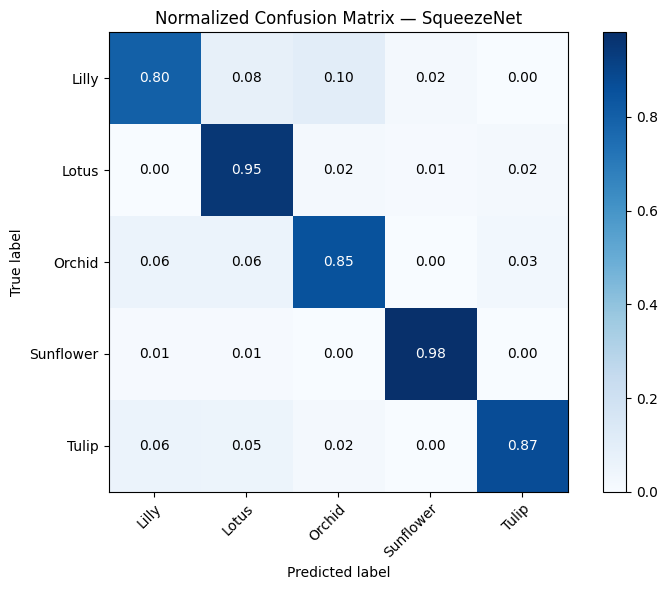

In [8]:
# Compute predictions across the entire test set for detailed metrics
@torch.no_grad()
def collect_preds(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(1).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(y.numpy())
    return np.concatenate(all_preds), np.concatenate(all_targets)

y_pred, y_true = collect_preds(sq, test_loader, device)
print("\nClassification Report (Test):\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

# Confusion matrix (normalized)
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(len(class_names)),
       yticks=np.arange(len(class_names)),
       xticklabels=class_names, yticklabels=class_names,
       ylabel='True label', xlabel='Predicted label',
       title='Normalized Confusion Matrix — SqueezeNet')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
# write values
thresh = cm_norm.max() / 2.
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}",
                ha="center", va="center",
                color="white" if cm_norm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

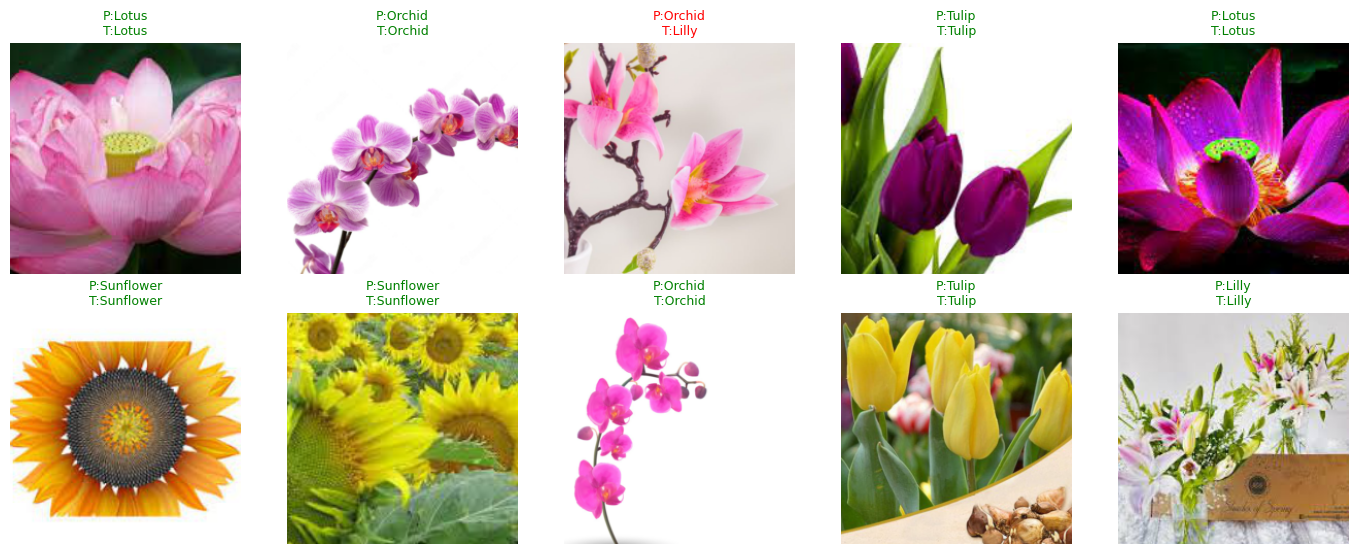

In [9]:
# ---- Visualize a few predictions ----
import math, random
def denormalize(img_tensor, mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)):
    if isinstance(mean, tuple): mean = torch.tensor(mean, device=img_tensor.device).view(3,1,1)
    if isinstance(std, tuple):  std  = torch.tensor(std,  device=img_tensor.device).view(3,1,1)
    return (img_tensor * std + mean).clamp(0,1)

@torch.no_grad()
def show_predictions_balanced(model, dataset, class_names, k_per_class=2, max_total=12):
    model.eval()
    targets = dataset.targets if hasattr(dataset, "targets") else [y for _, y in dataset]
    per_class = {c: [] for c in range(len(class_names))}
    for idx, y in enumerate(targets):
        per_class[int(y)].append(idx)

    chosen = []
    for c in range(len(class_names)):
        pool = per_class[c]
        if pool:
            k = min(k_per_class, len(pool))
            chosen += random.sample(pool, k)
    random.shuffle(chosen)
    chosen = chosen[:max_total]

    imgs, labels = [], []
    for i in chosen:
        img, y = dataset[i]
        imgs.append(img); labels.append(y)
    if not imgs:
        print("No images sampled. Check dataset path.");
    else:
        batch = torch.stack(imgs).to(device)
        labels = torch.tensor(labels, device=device)
        preds = model(batch).argmax(1)

        n = len(imgs); cols = min(5, n); rows = math.ceil(n/cols)
        plt.figure(figsize=(2.8*cols, 2.8*rows))
        for i in range(n):
            plt.subplot(rows, cols, i+1)
            disp = denormalize(batch[i].cpu()).permute(1,2,0)
            p, t = class_names[preds[i].item()], class_names[labels[i].item()]
            plt.imshow(disp); plt.axis("off")
            plt.title(f"P:{p}\nT:{t}", fontsize=9, color=("green" if p==t else "red"))
        plt.tight_layout(); plt.show()

show_predictions_balanced(sq, test_ds, class_names, k_per_class=2, max_total=20)

## Key Takeaways

- **SqueezeNet** uses **Fire modules** (1×1 squeeze → expand {1×1, 3×3}) and **late downsampling** to get **AlexNet‑level accuracy with ≪ parameters**.
- Replacing big FC layers with **1×1 conv + global average pooling** slashes parameters.
- **Parameter counts**: SqueezeNet ≪ GoogLeNet ≪ AlexNet ≪ VGG‑16 (approximate order), while accuracy remains competitive on many tasks.
- Using the **same flowers dataset** and **same evaluation code** keeps your comparisons **fair and consistent** across Practicals 7–10.


## Next Practical (Practical 11): **ResNet** - Going Deeper with Skip Connections

In the next notebook, we will study **ResNet**, which introduced **identity skip connections** to train very deep networks effectively.


---

*This practical was designed by **Dr. Zaid Al-Huda** to give you hands-on experience with SqueezeNet (v1.0), a clear comparison to AlexNet, VGG-16, and GoogLeNet, and practical skills in fine-tuning pretrained models, analyzing Fire modules, and counting parameters for efficient CNN design.*